In [8]:
import pandas as pd
import numpy as np
import sys
import shap
import xgboost as xgb
import pandas as pd
from src.features.feature_sets import get_feature_sets
import matplotlib.pyplot as plt
if ".." not in sys.path:
    sys.path.append("..")   

Valor base (media de la predicción): 72.49983
shape: (4319, 102)


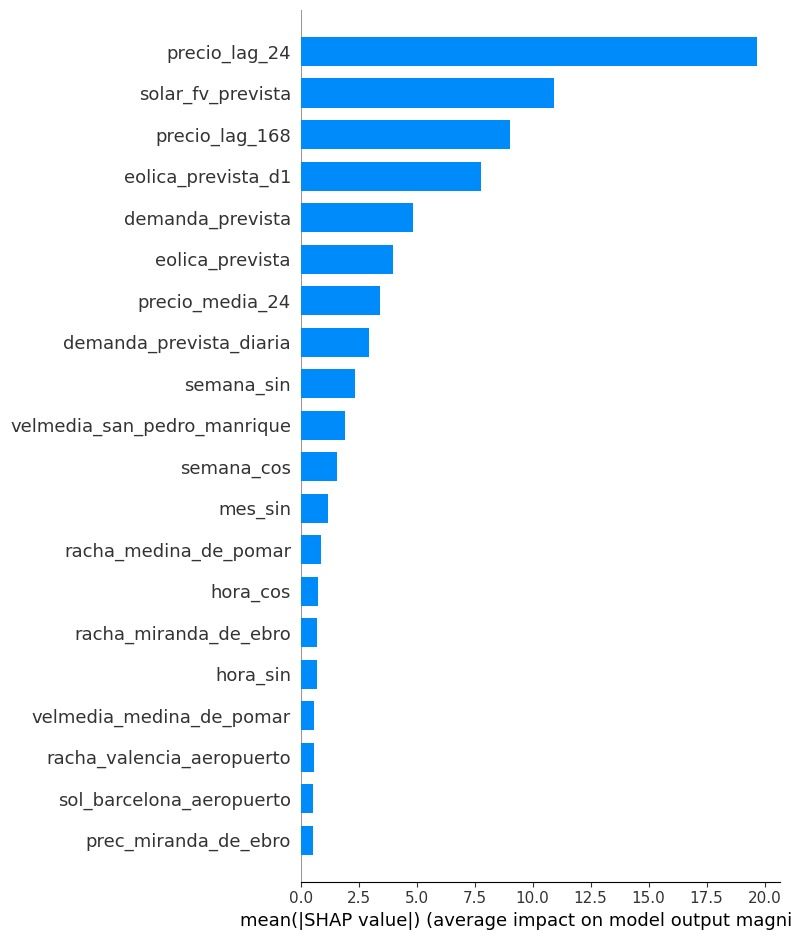

In [4]:
import shap
import xgboost as xgb
import pandas as pd
from src.features.feature_sets import get_feature_sets

TARGET = "precio_espana"
CUTOFF = pd.Timestamp("2026-01-01", tz="UTC")

dfx = pd.read_parquet("../data/processed/tabla_features.parquet")
dfx["datetime_utc"] = pd.to_datetime(dfx["datetime_utc"], utc=True)
dfx = dfx.sort_values("datetime_utc").set_index("datetime_utc")

feats = get_feature_sets(dfx)["predictivo"]
ent = dfx[dfx["entrenable"]]
tr = ent[ent.index <  CUTOFF]
te = ent[ent.index >= CUTOFF]

modelo_xgb = xgb.XGBRegressor(        # <-- tus hiperparámetros del nb 06
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)
modelo_xgb.fit(tr[feats], tr[TARGET])

# --- SHAP: explicador EXACTO para árboles (TreeSHAP) ---
explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer.shap_values(te[feats])     # (n_test, n_features), en €/MWh

print("Valor base (media de la predicción):", explainer.expected_value)
print("shape:", shap_values.shape)

# --- Importancia GLOBAL: ranking por media de |SHAP| ---
shap.summary_plot(shap_values, te[feats], plot_type="bar", max_display=20)

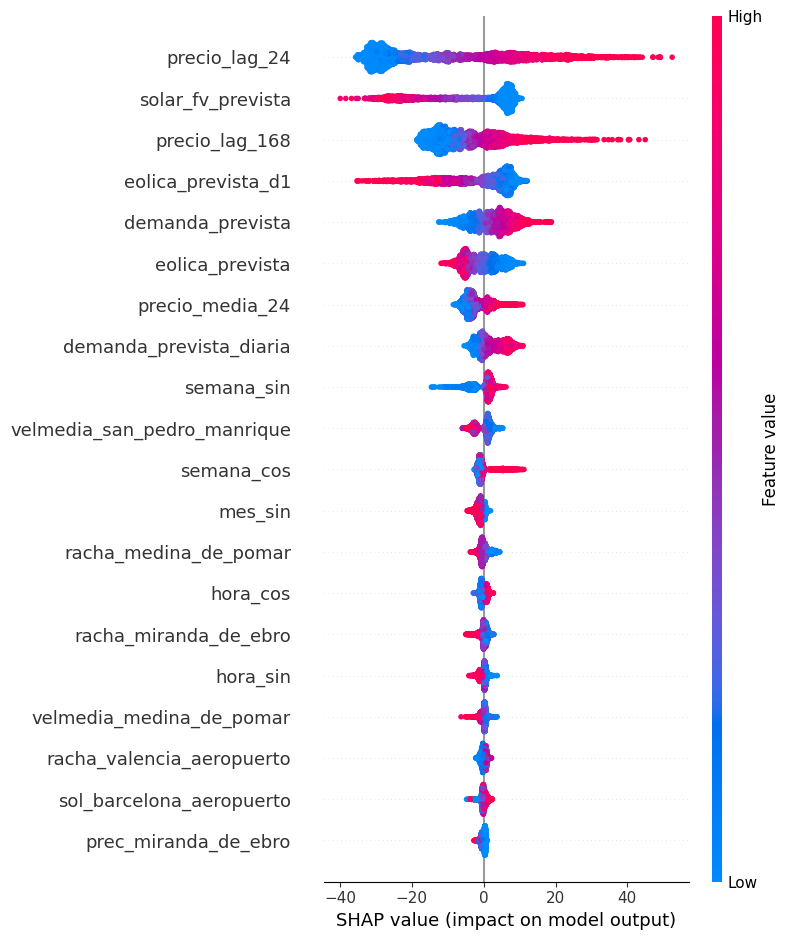

In [5]:
shap.summary_plot(shap_values, te[feats], max_display=20)

MÍN: 2026-03-29 14:00:00+00:00 | precio real: -9.8 €/MWh


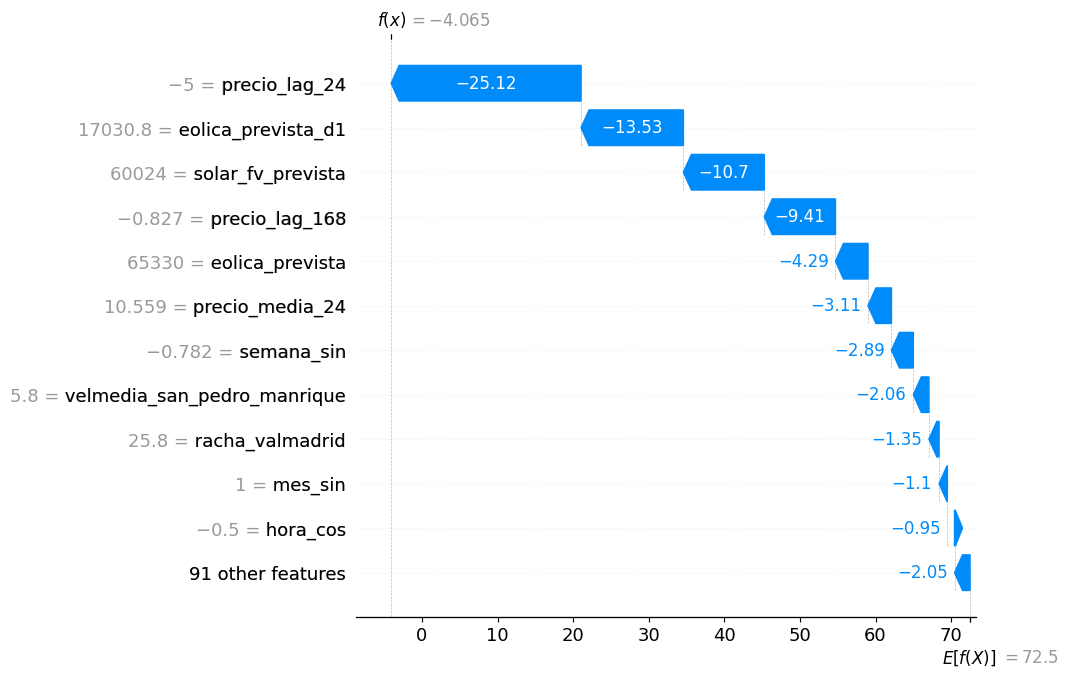

In [6]:
# Objeto Explanation para los waterfall locales
expl = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=te[feats].values,
    feature_names=list(feats),
)

i_bajo = te[TARGET].values.argmin()      # hora más barata/negativa del test
i_alto = te[TARGET].values.argmax()      # hora más cara

print("MÍN:", te.index[i_bajo], "| precio real:", round(te[TARGET].iloc[i_bajo], 1), "€/MWh")
shap.plots.waterfall(expl[i_bajo], max_display=12)

MÁX: 2026-03-10 19:00:00+00:00 | precio real: 193.8 €/MWh


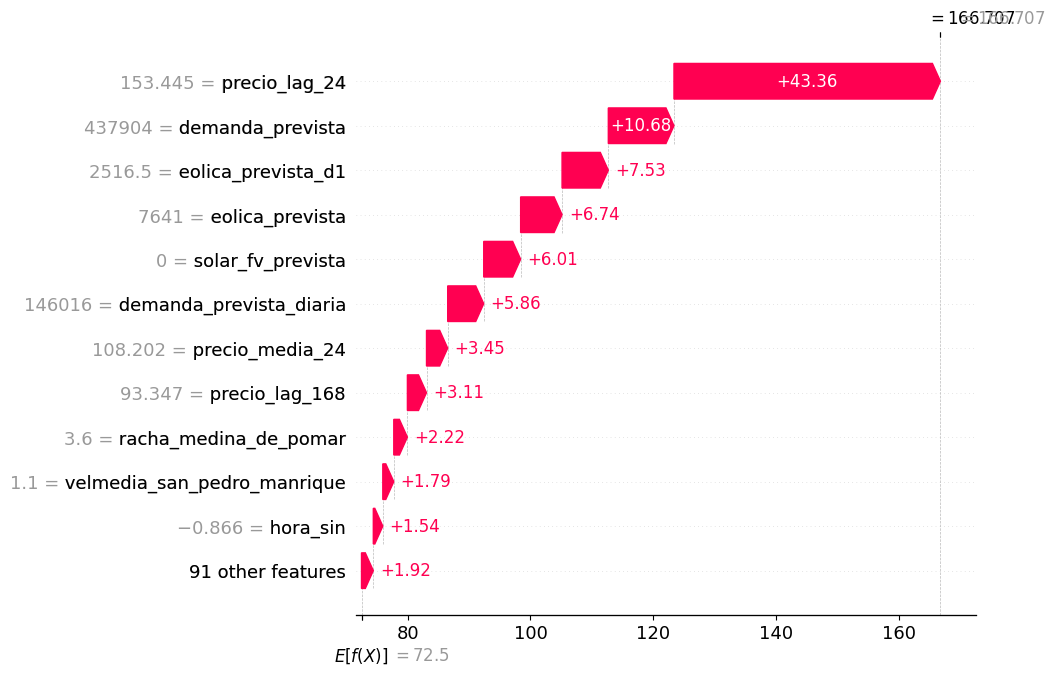

In [7]:
print("MÁX:", te.index[i_alto], "| precio real:", round(te[TARGET].iloc[i_alto], 1), "€/MWh")
shap.plots.waterfall(expl[i_alto], max_display=12)

In [9]:
import numpy as np


pred = modelo_xgb.predict(te[feats])
resid = te[TARGET].values - pred          # >0: infra-predice ; <0: sobre-predice

err = pd.DataFrame({
    "real": te[TARGET].values, "pred": pred, "resid": resid,
    "abs_err": np.abs(resid), "hora": te.index.hour,
}, index=te.index)

# 1) Global: MAE y SESGO
print("MAE :", round(err.abs_err.mean(), 2))
print("Bias (residuo medio):", round(err.resid.mean(), 2))

# 2) Por tramo de precio (aquí se ve dónde sufre)
err["tramo"] = pd.cut(err.real, [-np.inf, 0, 100, np.inf],
                      labels=["negativo (<0)", "normal (0-100)", "alto (>100)"])
print("\nPor tramo de precio (mean abs_err | mean resid | n):")
print(err.groupby("tramo", observed=True)[["abs_err", "resid"]].agg(["mean", "count"]).round(2))

# 3) Por hora del día
print("\nMAE por hora del día:")
print(err.groupby("hora")["abs_err"].mean().round(2))

MAE : 13.55
Bias (residuo medio): -3.58

Por tramo de precio (mean abs_err | mean resid | n):
               abs_err       resid      
                  mean count  mean count
tramo                                   
negativo (<0)     7.25   620 -5.03   620
normal (0-100)   14.97  2901 -6.61  2901
alto (>100)      13.26   798  8.54   798

MAE por hora del día:
hora
0     12.63
1     12.83
2     12.48
3     12.04
4     12.32
5     12.84
6     14.65
7     15.36
8     14.96
9     14.54
10    13.81
11    13.69
12    12.77
13    12.26
14    12.16
15    12.27
16    13.68
17    14.65
18    16.55
19    16.28
20    14.29
21    12.56
22    12.47
23    13.05
Name: abs_err, dtype: float64


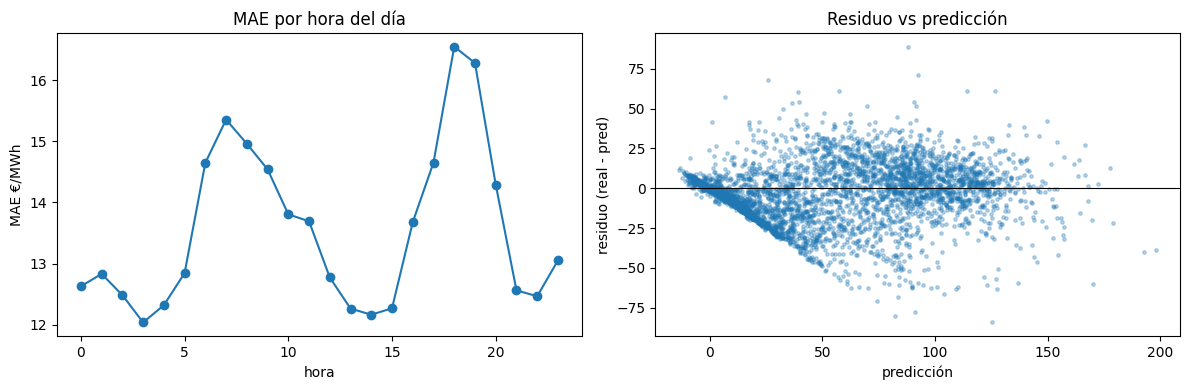

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
err.groupby("hora")["abs_err"].mean().plot(ax=ax[0], marker="o", title="MAE por hora del día")
ax[0].set_ylabel("MAE €/MWh")
ax[1].scatter(err.pred, err.resid, s=6, alpha=0.3)
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(title="Residuo vs predicción", xlabel="predicción", ylabel="residuo (real - pred)")
plt.tight_layout()

# Interpretabilidad del modelo — SpotPriceIQ

**Modelo:** XGBoost predictivo (modelo de referencia, MAE walk-forward ~15,7 €/MWh)
**Técnica:** SHAP (TreeSHAP, exacto para árboles)
**Datos de explicación:** holdout de 2026 (H1), entrenando con todo el histórico anterior

---

## 1. Importancia global — el merit order emerge solo

Ranking de variables por impacto medio (media de |SHAP|):

1. **precio_lag_24** (~19,7) — precio de la misma hora de ayer. Dominante.
2. **solar_fv_prevista** (~11) — previsión fotovoltaica.
3. **precio_lag_168** (~9) — precio de la misma hora la semana pasada.
4. **eolica_prevista_d1** (~7,8) — previsión eólica D+1.
5. **demanda_prevista** (~4,9) y **eolica_prevista** (~4) — versiones genéricas.
6. **precio_media_24**, **demanda_prevista_diaria** — persistencia y demanda D+1.
7. Calendario (día de semana, mes, hora) — aportación moderada.
8. **Bloque meteo (AEMET)** — `velmedia_*`, `racha_*`, `sol_*`, `prec_*`: al fondo, aportación marginal.

**Lecturas clave:**

- **Esqueleto autorregresivo:** los lags de precio (24 h y 168 h, ambos legales día-antes) son el mayor driver → persistencia + estacionalidad diaria y semanal. El modelo mira primero "cuánto costó esta hora ayer/la semana pasada", como haría un trader.
- **Fundamentales en su sitio:** tras los lags, mandan renovables y demanda previstas. La solar FV como fundamental #1 encaja con el régimen de 2026 (mucha fotovoltaica hunde el precio a mediodía).
- **El meteo crudo es redundante:** confirma empíricamente la decisión de excluirlo — las previsiones de cantidad (`eolica_prevista`, `solar_fv_prevista`) ya lo tienen "digerido".

---

## 2. Explicaciones locales — dos horas extremas

### Hora de precio negativo (predicción −4,07 €/MWh, base 72,5)
Todos los contribuyentes empujan hacia abajo:
- `precio_lag_24 = −5` → **−25,1** (ayer ya fue negativa: persistencia del régimen bajo)
- `eolica_prevista_d1` (alta) → **−13,5** · `solar_fv_prevista` (alta) → **−10,7** · `eolica_prevista` → **−4,3**
- Renovables juntas ≈ **−28 €** → *el mecanismo de los precios negativos hecho explícito.*

### Hora de precio alto (predicción 166,7 €/MWh, base 72,5)
La historia espejo, todo hacia arriba:
- `precio_lag_24 = 153` → **+43,4** (ayer carísimo)
- `demanda_prevista` (alta) → **+10,7**
- `eolica_prevista_d1` (**baja**, ~2.500) → **+7,5** · `solar_fv_prevista = 0` → **+6,0** → *escasez de renovables sube el precio.*

Las mismas variables **voltean el signo con sentido físico**: la solar resta cuando abunda y suma cuando falta. El modelo entiende la escasez/abundancia, no memoriza.

---

## 3. Análisis de errores — sesgo de régimen y colas

Sobre el holdout de 2026: **MAE 13,55 €/MWh**, y **sesgo (residuo medio) = −3,58** → el modelo **sobre-predice de media**.

| Tramo de precio | MAE | Residuo medio | n |
|---|---|---|---|
| Negativo (<0) | 7,25 | **−5,03** (sobre-predice) | 620 |
| Normal (0–100) | 14,97 | **−6,61** (sobre-predice) | 2901 |
| Alto (>100) | 13,26 | **+8,54** (infra-predice) | 798 |

**Patrón = encogimiento hacia el régimen viejo.** El valor base (72,5 €) está anclado al régimen caro de entrenamiento (2024–25); en el régimen bajo de 2026 el modelo tira demasiado alto. Sobre-predice lo bajo/normal e infra-predice los picos: no alcanza los extremos en ninguna dirección.

**Error por hora del día:** dos picos — mañana (7–9 h, ~15) y tarde (18–19 h, ~16,5, el peor) — y calma de noche (~12) y a mediodía (~12,2). El error se concentra en las **rampas** (máxima volatilidad oferta-demanda); las bandas estables se predicen bien.

---

## 4. Síntesis y conexión con el proyecto

La interpretabilidad triangula, desde tres ángulos independientes, el hilo central del proyecto — **la no-estacionariedad**:

- **Global/local:** el modelo razona por merit order (demanda ↑ precio; renovables ↓ precio; persistencia).
- **Errores:** su debilidad es (1) un **sesgo al alza por anclaje al régimen de entrenamiento** (−3,58) y (2) la **incapacidad de alcanzar los extremos y las horas volátiles**.

Todo apunta al mismo sitio que el punto (fallo en primavera-2024) y los intervalos (cola baja de la Fase 5.3): la respuesta es la **recalibración / reentrenamiento adaptativo (Bloque 10)**. De hecho, el sesgo de −3,58 es corregible de forma barata restando una estimación reciente del residuo — la versión mínima de esa recalibración adaptativa.
